In [2]:
import numpy as np
import scipy
import scipy.special as sp
import matplotlib.pyplot as plt
import h5py

from vgh_2d import WfnParams as WfnParams_vgh
from vgh_2d import eom, energy

In [3]:
def get_e_vgh_for_coupling(dir,init,Mx,My,tx,ty,qx,qy,B,V_0_arr):
    e_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_T_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_V_arr = np.zeros(len(V_0_arr), dtype=complex)
    e_B_arr = np.zeros(len(V_0_arr), dtype=complex)

    Tx_arr = np.zeros(len(V_0_arr), dtype=complex)
    Ty_arr = np.zeros(len(V_0_arr), dtype=complex)

    for i in range(len(V_0_arr)):
        V_0 = V_0_arr[i]
        file_path = dir+'data_'+str(init)+'_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_qx_'+str(qx)+'_qy_'+str(qy)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

        with h5py.File(file_path, 'r') as f:
            phi_data = f["wfn"][...]
            Mx = f["Mx"][...]
            My = f["My"][...]
            n = f["n"][...]
            B = f["B"][...]
            tx = f["tx"][...]
            ty = f["ty"][...]
            qx = f["qx"][...]
            qy = f["qy"][...]
            V_0 = f["V0"][...]

        params = {"n": n, "Mx": Mx, "My": My, "B": B, "tx": tx, "ty": ty, "V_0": V_0, "qx": qx, "qy": qy}

        energy_object = energy(params=params)
        E = energy_object.calc_energy(phi_data)
        Tx, Ty = energy_object.deriv_dE_dt(phi_data)

        e_arr[i] = E[0] 
        e_T_arr[i] = E[1]
        e_B_arr[i] = E[2]
        e_V_arr[i] = E[3]
        
        Tx_arr[i] = Tx
        Ty_arr[i] = Ty
        
    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

def get_state_e_vgh_data(dir,Mx,My,tx_arr,ty_arr,qx,qy,B,V_0_arr):
    e_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)

    e_T_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    e_B_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    e_V_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    
    Tx_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    Ty_arr = np.zeros((4,len(tx_arr),len(V_0_arr)), dtype=complex)
    for i in range(len(tx_arr)):
        tx = tx_arr[i]
        ty = ty_arr[i]

        init = 'uniform'
        e_flp, e_flp_T, e_flp_B, e_flp_V, Tx_flp, Ty_flp = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'fdv'
        e_fdv, e_fdv_T, e_fdv_B, e_fdv_V, Tx_fdv, Ty_fdv = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'fdh'
        e_fdh, e_fdh_T, e_fdh_B, e_fdh_V, Tx_fdh, Ty_fdh = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        init = 'sp'
        e_sp, e_sp_T, e_sp_B, e_sp_V, Tx_sp, Ty_sp = get_e_vgh_for_coupling(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

        e_arr[0,i] = e_flp
        e_arr[1,i] = e_fdv
        e_arr[2,i] = e_fdh
        e_arr[3,i] = e_sp

        e_T_arr[0,i] = e_flp_T
        e_T_arr[1,i] = e_fdv_T
        e_T_arr[2,i] = e_fdh_T
        e_T_arr[3,i] = e_sp_T

        e_B_arr[0,i] = e_flp_B
        e_B_arr[1,i] = e_fdv_B
        e_B_arr[2,i] = e_fdh_B
        e_B_arr[3,i] = e_sp_B
        
        e_V_arr[0,i] = e_flp_V
        e_V_arr[1,i] = e_fdv_V
        e_V_arr[2,i] = e_fdh_V
        e_V_arr[3,i] = e_sp_V

        Tx_arr[0,i] = Tx_flp
        Tx_arr[1,i] = Tx_fdv
        Tx_arr[2,i] = Tx_fdh
        Tx_arr[3,i] = Tx_sp

        Ty_arr[0,i] = Ty_flp
        Ty_arr[1,i] = Ty_fdv
        Ty_arr[2,i] = Ty_fdh
        Ty_arr[3,i] = Ty_sp
        
    return e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr

def get_Px_Py(dir,init,Mx,My,tx,ty,qx,qy,B,V_0):
    file_path = dir+'data_'+str(init)+'_B_'+str(B)+'_V0_'+str(V_0)+'_tx_'+str(tx)+'_ty_'+str(ty)+'_qx_'+str(qx)+'_qy_'+str(qy)+'_'+str(int(Mx))+'x'+str(int(My))+'.h5'

    with h5py.File(file_path, 'r') as f:
        phi_data = f["wfn"][...]
        Mx = f["Mx"][...]
        My = f["My"][...]
        n = f["n"][...]
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        qx = f["qx"][...]
        qy = f["qy"][...]
        V_0 = f["V0"][...]

    wfnpar = WfnParams_vgh(Mx, My, n)
    Mx, My, n, x, k2 = wfnpar.read()

    P_arr = np.zeros((My,Mx), dtype=complex)
    Px_arr = np.zeros((My,Mx), dtype=complex)
    Py_arr = np.zeros((My,Mx), dtype=complex)
    for i in range(My):
        for j in range(Mx):
            Px = np.sum(np.cos(x)*np.abs(phi_data[i,j,:])**2) 
            Py = np.sum(np.sin(x)*np.abs(phi_data[i,j,:])**2)

            P_arr[i,j] = (Px**2 + Py**2)**0.5
            Px_arr[i,j] = Px
            Py_arr[i,j] = Py

    return P_arr, Px_arr, Py_arr

def get_Px_Py_4_states(dir,init,Mx,My,tx,ty,qx,qy,B,V_0):
    init = 'uniform'
    P_flp, Px_flp, Py_flp = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    init = 'fdv'
    P_fdv, Px_fdv, Py_fdv = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    init = 'fdh'
    P_fdh, Px_fdh, Py_fdh = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    init = 'sp'
    P_sp, Px_sp, Py_sp = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

    P = [P_flp, P_fdv, P_fdh, P_sp]
    Px = [Px_flp, Px_fdv, Px_fdh, Px_sp]
    Py = [Py_flp, Py_fdv, Py_fdh, Py_sp]
    
    return P, Px, Py

def outfold_array(psi):
    My = psi.shape[0]
    Mx = psi.shape[1]
    
    psi_n = psi.copy()
    for i in range(My):
        for j in range(Mx):
            psi_ij = psi[(i+int(My/2))%My,(j+int(Mx/2))%Mx] 
            psi_n[i,j] = psi_ij
    return psi_n

# Energy Characteristics

In [4]:
'''
Example Test for one delta_t value, i.e. one lattice symmetry
'''
V_0_arr = np.array([0.7])

Mx = 10
My = 10
tx = 0.5
ty = 0.5
B = 1e-2

qx=0.0
qy=0.0

init = 'uniform'
dir_sym = 'data_vgh/'
e, e_T, e_B, e_V, Tx, Ty = get_e_vgh_for_coupling(dir=dir_sym,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr)

print('E     =', e, '\nE_T   =', e_T, '\nE_B   =', e_B, '\nE_V   =', e_V, '\nTx    =', Tx, '\nTy    =', Ty)

E     = [-2.63927343+1.2509549e-20j] 
E_T   = [-1.2829893-2.11852294e-33j] 
E_B   = [0.0092597+1.2509549e-20j] 
E_V   = [-1.36554383+0.j] 
Tx    = [-1.2829893+3.85185989e-34j] 
Ty    = [-1.2829893-4.62223187e-33j]


In [5]:
'''
Get State Properties for a phase diagram scan in the delta_t-V_0 plane
'''
V_0_arr = np.array([0.0,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4,2.6])

Mx = 10
My = 10
tx_arr = np.array([0.5,0.6,0.7,0.8,0.9,1.0])
ty_arr = np.array([0.5,0.4,0.3,0.2,0.1,0.0])
B = 1e-2

qx=0.0
qy=0.0

dir='data_vgh/'
e_arr, e_T_arr, e_B_arr, e_V_arr, Tx_arr, Ty_arr = get_state_e_vgh_data(dir=dir,Mx=Mx,My=My,tx_arr=tx_arr,ty_arr=ty_arr,qx=qx,qy=qx,B=B,V_0_arr=V_0_arr)

tx = 0.5  ty = 0.5


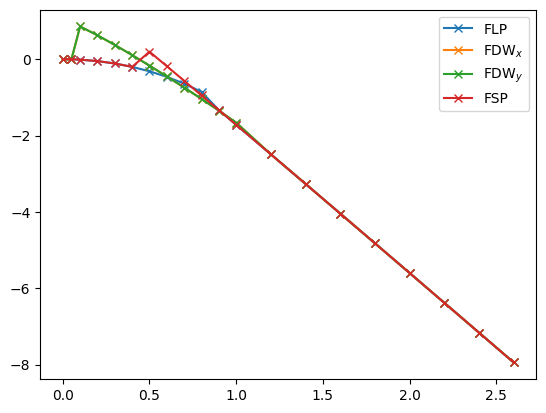

In [6]:
delta_t_index = 0
print('tx =', tx_arr[delta_t_index], ' ty =', ty_arr[delta_t_index])

plt.plot(V_0_arr, e_arr[0,delta_t_index].real+2, marker='x', label=r'FLP')
plt.plot(V_0_arr, e_arr[2,delta_t_index].real+2, marker='x', label=r'FDW$_x$')
plt.plot(V_0_arr, e_arr[1,delta_t_index].real+2, marker='x', label=r'FDW$_y$')
plt.plot(V_0_arr, e_arr[3,delta_t_index].real+2, marker='x', label=r'FSP')

plt.legend()

# Phase Diagram

## In $\Delta_t - V_0$ plane

### Interpolation

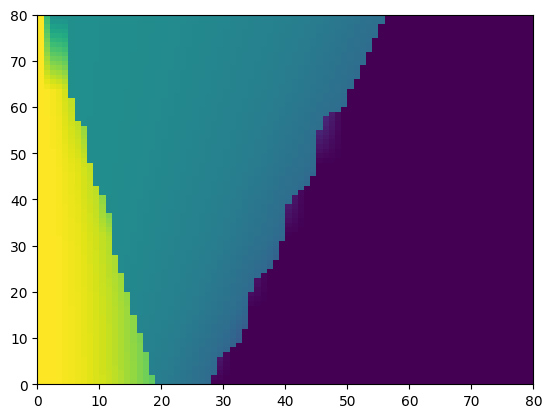

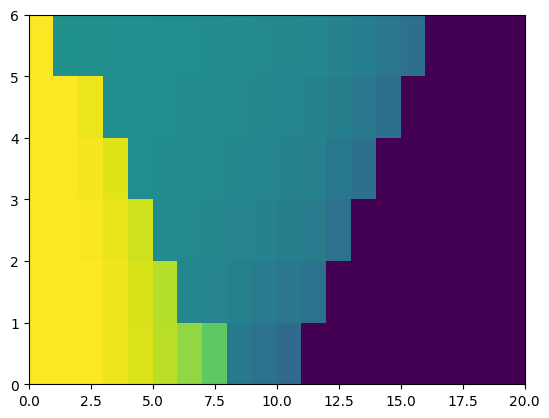

In [7]:
def get_gs_phase_diagram(e_arr,Tx_arr,Ty_arr):
    e_gs = np.zeros(e_arr[0,:].shape, dtype=complex)
    Tx_gs = np.zeros(e_arr[0,:].shape, dtype=complex)
    Ty_gs = np.zeros(e_arr[0,:].shape, dtype=complex)
    for i in range(e_gs.shape[0]):
        for j in range(e_gs.shape[1]):
            e_index = np.argsort(e_arr[:,i,j])
        
            e_gs[i,j] = e_arr[e_index,i,j][0]
            Tx_gs[i,j] = Tx_arr[e_index,i,j][0]
            Ty_gs[i,j] = Ty_arr[e_index,i,j][0]
    return e_gs, Tx_gs, Ty_gs
    
def interpolate_data(x,y,x_points,y_points,data):    
    f = scipy.interpolate.RegularGridInterpolator((x.real, y.real), data.real, bounds_error=False, fill_value=None)
    
    Xnew = np.linspace(x[0].real, x[-1].real, x_points)
    Ynew = np.linspace(y[0].real, y[-1].real, y_points)
    Xnew, Ynew = np.meshgrid(Xnew, Ynew, indexing='ij')

    data_new = f((Xnew,Ynew), method='linear')
    return Xnew, Ynew, data_new

def create_interp_array(x,y,x_points,y_points,arr):
    arr_interp = np.zeros((4,x_points,y_points))
    
    X_intp, Y_intp, arr_interp[0] = interpolate_data(x,y,x_points,y_points,arr[0].real)
    X_intp, Y_intp, arr_interp[1] = interpolate_data(x,y,x_points,y_points,arr[1].real)
    X_intp, Y_intp, arr_interp[2] = interpolate_data(x,y,x_points,y_points,arr[2].real)
    X_intp, Y_intp, arr_interp[3] = interpolate_data(x,y,x_points,y_points,arr[3].real)

    return X_intp, Y_intp, arr_interp
    
delta_t = tx_arr-ty_arr
x_points = 80
y_points = 80

X_intp, Y_intp, e_arr_interp = create_interp_array(delta_t,V_0_arr,x_points,y_points,e_arr)
X_intp, Y_intp, Tx_arr_interp = create_interp_array(delta_t,V_0_arr,x_points,y_points,Tx_arr)
X_intp, Y_intp, Ty_arr_interp = create_interp_array(delta_t,V_0_arr,x_points,y_points,Ty_arr)

e_gs, Tx_gs, Ty_gs = get_gs_phase_diagram(e_arr,Tx_arr,Ty_arr)
e_gs_interp, Tx_gs_interp, Ty_gs_interp = get_gs_phase_diagram(e_arr_interp,Tx_arr_interp,Ty_arr_interp)

plt.pcolormesh(np.abs(Tx_gs_interp+Ty_gs_interp)); plt.show()
plt.pcolormesh(np.abs(Tx_gs+Ty_gs))

In [8]:
def plot_delta_t_phase_diagram(x,y,m_size,Tx,Ty,file_save):
    A = 6
    plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    font_size = 20 # 14

    fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

    y1 = -y.copy()

    x_points = len(x)
    y_points = len(y) 
    
    img1 = np.ones((y_points,x_points,3)) # image for upper half
    img2 = np.ones((y_points,x_points,3)) # image for lower half
    
    '''
    A very simple colormap:
    #  mapping parameter 1 to the red channel and 
    #          parameter 2 to the blue channel
    '''
    green_frac = 0.83
    cmap = lambda p1,p2 : ((1-np.abs(p1/2))**(1/3), green_frac, (1-np.abs(p2/2))**(1/3))
    
    p1 = Tx
    p2 = Ty
    for j in range(len(y)):
        for i in range(len(x)):
            plt.plot(x[i], y[j], marker="s", markersize=m_size, color=cmap(p1[j,i],p2[j,i]))
            plt.plot(x[i], y1[j], marker="s", markersize=m_size, color=cmap(p2[j,i],p1[j,i]))

            img1[j,i] = cmap(p1[j,i],p2[j,i])
            img2[j,i] = cmap(p2[j,i],p1[j,i])

    ax.annotate(r'FLP', xy=(0.2, -0.1), xytext=(0.2, -0.051), fontsize=20, color='black')
    ax.annotate(r'FDW$_x$', xy=(0.2, 0), xytext=(0.6, 0.6), fontsize=20, color='black')
    ax.annotate(r'FDW$_y$', xy=(0.2, 0), xytext=(0.6, -0.7), fontsize=20, color='black')
    ax.annotate(r'FSP', xy=(0.2, -0.1), xytext=(1.3, -0.051), fontsize=20, color='black')

    plt.xlim(0,2)
    plt.ylim(-1,1)

    plt.xlabel(r'$V_0/t$', fontsize=font_size)
    plt.ylabel(r'$\Delta_t$', fontsize=font_size)

    plt.xticks([0,0.5,1,1.5,1.75],[r'0.0',r'0.5',r'1.0',r'1.5',r''], fontsize=font_size)
    plt.yticks([-1,-0.5,0,0.5,1],[r'-1.0',r'-0.5',r'0.0',r'0.5',r'1.0'], fontsize=font_size)

    plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7) # 4
    plt.tick_params(axis='y', direction='in', length=6, right=True)

    plt.tick_params(which='minor', axis='y', direction='in', right=True)

    plt.subplots_adjust(left=0.1, right=0.65, top=0.85)
    cax = fig.add_axes([0.54,0.7,0.1,0.1]) #([0.54,0.7,0.1,0.1]) #fig.add_axes([0.72,0.55,0.3,0.3])
    cp1 = np.linspace(0, 1, 100)
    cp2 = np.linspace(0, 1, 100)
    Cp1, Cp2 = np.meshgrid(cp1,cp2)
    C0 = green_frac*np.ones_like(Cp2)
    # make RGB image, p1 to red channel, p2 to blue channel
    Legend = np.dstack(((1-Cp1)**(1/3),C0,(1-Cp2)**(1/3)))

    # parameters range between 0 and 1
    cax.imshow(Legend, origin="lower", extent=[0,2,0,2])
    cax.set_xticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_yticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_xlabel(r'$\mathcal{T}_x$', fontsize=0.75*font_size)
    cax.set_ylabel(r'$\mathcal{T}_y$', fontsize=0.75*font_size)

    plt.show()
    #plt.savefig(file_save, bbox_inches='tight', dpi=500, transparent=True)
    return img1, img2

'''
This plotting routine just fills white gaps in the plot - can be useful for irregular grids!
'''
def plot_delta_t_phase_diagram_img(x,y,img1,img2,file_save):
    A = 6
    plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    font_size = 20 # 14

    fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

    Xgrid, Ygrid = np.meshgrid(y, x, indexing='ij')

    plt.pcolormesh(Ygrid, Xgrid, img1, antialiased=True, rasterized=True)
    plt.pcolormesh(Ygrid, -Xgrid, img2, antialiased=True, rasterized=True)

    ax.annotate(r'FLP', xy=(0.2, -0.1), xytext=(0.2, -0.051), fontsize=20, color='black')
    ax.annotate(r'FDW$_x$', xy=(0.2, 0), xytext=(0.6, 0.6), fontsize=20, color='black')
    ax.annotate(r'FDW$_y$', xy=(0.2, 0), xytext=(0.6, -0.7), fontsize=20, color='black')
    ax.annotate(r'FSP', xy=(0.2, -0.1), xytext=(1.3, -0.051), fontsize=20, color='black')

    plt.xlim(0,2)
    plt.ylim(-1,1)

    plt.xlabel(r'$V_0/t$', fontsize=font_size)
    plt.ylabel(r'$\Delta_t$', fontsize=font_size)

    plt.xticks([0,0.5,1,1.5,1.75],[r'0.0',r'0.5',r'1.0',r'1.5',r''], fontsize=font_size)
    plt.yticks([-1,-0.5,0,0.5,1],[r'-1.0',r'-0.5',r'0.0',r'0.5',r'1.0'], fontsize=font_size)

    plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7) # 4
    plt.tick_params(axis='y', direction='in', length=6, right=True)

    plt.tick_params(which='minor', axis='y', direction='in', right=True)

    green_frac = 0.83
    
    plt.subplots_adjust(left=0.1, right=0.65, top=0.85)
    cax = fig.add_axes([0.54,0.7,0.1,0.1]) #([0.54,0.7,0.1,0.1]) #fig.add_axes([0.72,0.55,0.3,0.3])
    cp1 = np.linspace(0, 1, 100)
    cp2 = np.linspace(0, 1, 100)
    Cp1, Cp2 = np.meshgrid(cp1,cp2)
    C0 = green_frac*np.ones_like(Cp2)
    # make RGB image, p1 to red channel, p2 to blue channel
    Legend = np.dstack(((1-Cp1)**(1/3),C0,(1-Cp2)**(1/3)))

    # parameters range between 0 and 1
    cax.imshow(Legend, origin="lower", extent=[0,2,0,2])
    cax.set_xticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_yticks([0,1,2], [r'0',r'1',r'2'], fontsize=0.75*font_size)
    cax.set_xlabel(r'$\mathcal{T}_x$', fontsize=0.75*font_size)
    cax.set_ylabel(r'$\mathcal{T}_y$', fontsize=0.75*font_size)

    #plt.savefig(file_save, bbox_inches='tight', dpi=500, transparent=True)

### Plotting the Energy

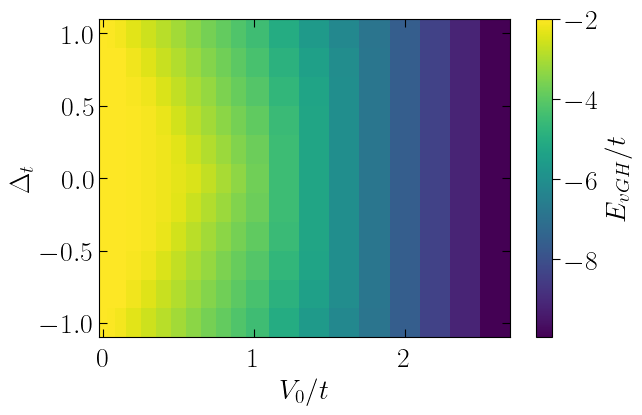

In [9]:
'''Raw Data: Without Interpolation'''
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20 # 14

fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

pc = plt.pcolormesh(X,Y,e_gs.real, antialiased=False)
pc = plt.pcolormesh(X,-Y,e_gs.real, antialiased=False)
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$E_{vGH}/t$', size=20)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

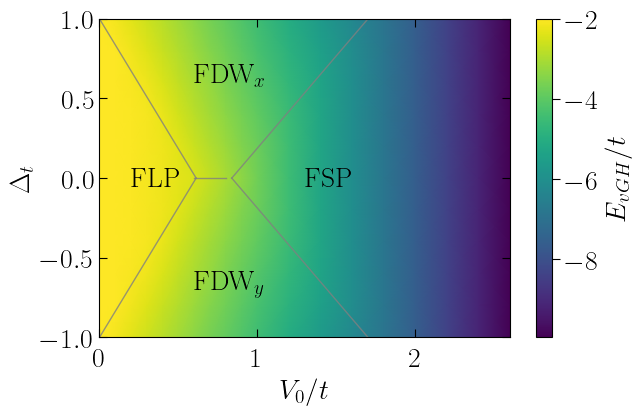

In [10]:
'''With Interpolation'''
X, Y = np.meshgrid(V_0_arr, tx_arr-ty_arr)

A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20 # 14

fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

pc = plt.pcolormesh(X,Y,e_gs.real, antialiased=False, shading='gouraud') #, cmap='gnuplot')
pc = plt.pcolormesh(X,-Y,e_gs.real, antialiased=False, shading='gouraud') #, cmap='gnuplot')
cbar = fig.colorbar(pc)
cbar.ax.tick_params(length=6, labelsize=font_size)
cbar.set_label(label=r'$E_{vGH}/t$', size=20)

ax.annotate(r'FLP', xy=(0.2, -0.1), xytext=(0.2, -0.051), fontsize=20, color='black')
ax.annotate(r'FDW$_x$', xy=(0.2, 0), xytext=(0.6, 0.6), fontsize=20, color='black')
ax.annotate(r'FDW$_y$', xy=(0.2, 0), xytext=(0.6, -0.7), fontsize=20, color='black')
ax.annotate(r'FSP', xy=(0.2, -0.1), xytext=(1.3, -0.051), fontsize=20, color='black')

plt.plot(np.array([0,0.612]), np.array([1,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
plt.plot(np.array([0,0.612]), np.array([-1,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
plt.plot(np.array([0.8375,1.7]), np.array([0,1]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
plt.plot(np.array([0.8375,1.7]), np.array([0,-1]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)
plt.plot(np.array([0.6,0.8]), np.array([0,0]), linestyle='solid', color='grey', linewidth=1, alpha=0.8)

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$\Delta_t$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size)
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

### Plotting the Order Parameter

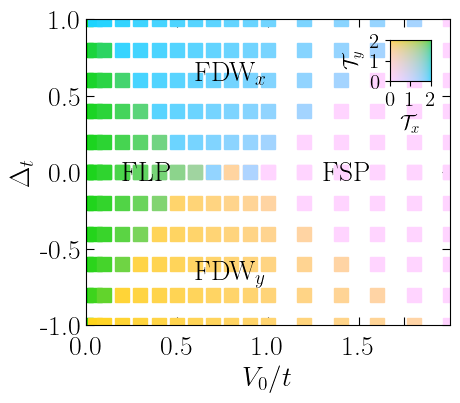

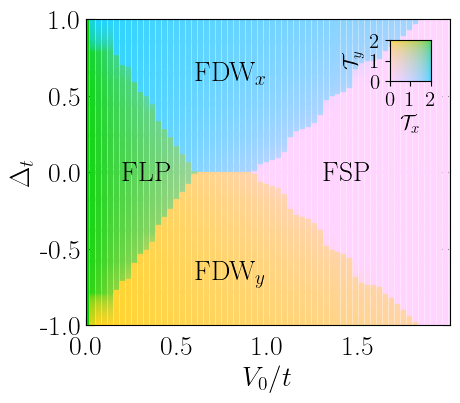

In [11]:
delta_t = tx_arr-ty_arr
img1, img2 = plot_delta_t_phase_diagram(x=V_0_arr,y=delta_t,m_size=10,Tx=Tx_gs,Ty=Ty_gs,file_save='results/pd_delta_t_B_1e-2t.png')

x_intp = np.linspace(V_0_arr[0], V_0_arr[-1], x_points)
y_intp = np.linspace(delta_t[0], delta_t[-1], y_points)

img1_intp, img2_intp = plot_delta_t_phase_diagram(x=x_intp,y=y_intp,m_size=3,Tx=Tx_gs_interp,Ty=Ty_gs_interp,file_save='results/pd_intp_delta_t_B_1e-2t.png')

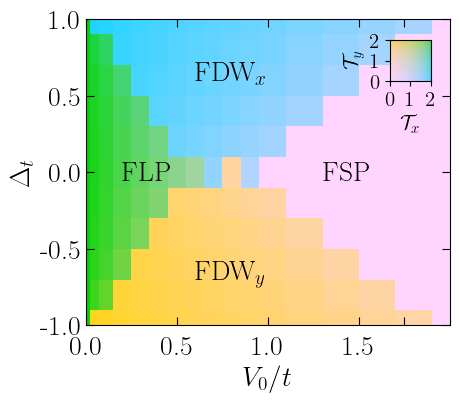

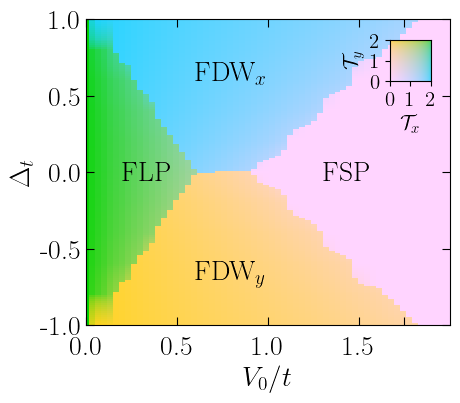

In [12]:
plot_delta_t_phase_diagram_img(x=V_0_arr,y=delta_t,img1=img1,img2=img2,file_save='results/pd_delta_t_B_1e-2t.png')
plot_delta_t_phase_diagram_img(x=x_intp,y=y_intp,img1=img1_intp,img2=img2_intp,file_save='results/pd_delta_t_B_1e-2t.png')

### Detail of the Order Parameter

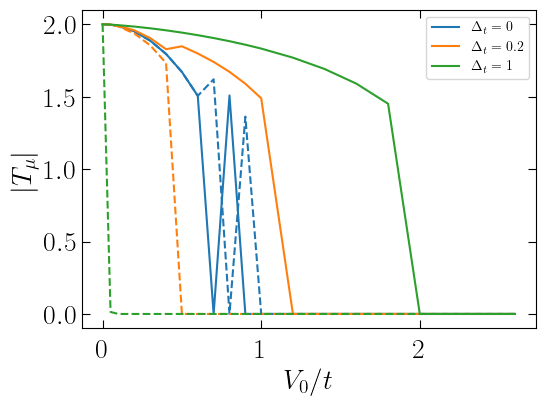

In [13]:
i = 0
plt.plot(V_0_arr, np.abs(Tx_gs[i].real), linestyle='solid', color='tab:blue', label=r'$\Delta_t = 0$')
plt.plot(V_0_arr, np.abs(Ty_gs[i].real), linestyle='dashed', color='tab:blue')

i = 1
plt.plot(V_0_arr, np.abs(Tx_gs[i].real), linestyle='solid', color='tab:orange', label=r'$\Delta_t = 0.2$')
plt.plot(V_0_arr, np.abs(Ty_gs[i].real), linestyle='dashed', color='tab:orange')

i = 5
plt.plot(V_0_arr, np.abs(Tx_gs[i].real), linestyle='solid', color='tab:green', label=r'$\Delta_t = 1$')
plt.plot(V_0_arr, np.abs(Ty_gs[i].real), linestyle='dashed', color='tab:green')

plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$|T_{\mu}|$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend()

# Comparison vGH - BW

## Energy Comparison

V_0, = 0.0001 , E0 = -1.2529578989050514e-08
V_0, = 0.0005 , E0 = -3.1323934385211156e-07
V_0, = 0.001 , E0 = -1.2529557331635518e-06
V_0, = 0.005 , E0 = -3.132260855073727e-05
V_0, = 0.01 , E0 = -0.00012527440761950839
V_0, = 0.05 , E0 = -0.0031194273860504457
V_0, = 0.1 , E0 = -0.012336875143503154
V_0, = 0.5 , E0 = -0.25406304373337146
V_0, = 1.0 , E0 = -0.7764779788038526


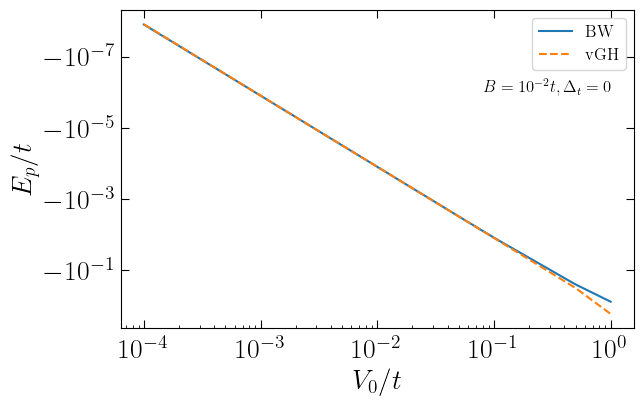

In [89]:
def read_bw_pert_result(dir,V_0,B,tx,ty):
    file_path = dir+'data_V0_'+str(V_0)+'_B_'+str(B)+'_tx_'+str(tx)+'_ty_'+str(ty)+'.h5'

    with h5py.File(file_path, 'r') as f:
        B = f["B"][...]
        tx = f["tx"][...]
        ty = f["ty"][...]
        V_0 = f["V0"][...]
        ebw = f["ebw"][...]

    return ebw

def read_bw(dir,V_0_arr,B,tx,ty):
    ebw_arr = np.zeros(len(V_0_arr), dtype=complex)
    
    for i in range(len(V_0_arr)):
        ebw =  read_bw_pert_result(dir,V_0_arr[i],B,tx,ty)

        ebw_arr[i] = ebw
        
        print('V_0, =',V_0_arr[i],', E0 =',ebw)

    return ebw_arr

'''Read BW'''

V_0_arr_bw = np.array([0.0001,0.0005,0.001,0.005,0.01,0.05,0.1,0.5,1])

B = 0.01
tx = 0.5
ty = 0.5

dir = 'data_bw/'
ebw_arr = read_bw(dir,V_0_arr_bw,B,tx,ty)

'''Read vGH'''
Mx = 30
My = 30
tx = 0.5
ty = 0.5
B = 1e-2

qx=0.0
qy=0.0

init = 'uniform'
dir_sym = 'data_vgh/'
ebw_vgh_arr, ebw_T_vgh_arr, ebw_B_vgh_arr, ebw_V_vgh_arr, Txbw_vgh_arr, Tybw_vgh_arr = get_e_vgh_for_coupling(dir=dir_sym,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0_arr=V_0_arr_bw)


'''Plot'''
fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

plt.plot(V_0_arr_bw, np.abs(ebw_arr.real), linestyle='solid', label=r'BW')
plt.plot(V_0_arr_bw, np.abs(ebw_vgh_arr.real+2), linestyle='dashed', label=r'vGH')

ax.invert_yaxis()

plt.xscale('log')
plt.yscale('log')

ax.annotate(r'$B=10^{-2}t, \Delta_t = 0$', xy=(0.08, 1e-6), fontsize=0.6*font_size, color='black')
   
plt.xlabel(r'$V_0/t$', fontsize=font_size)
plt.ylabel(r'$E_p/t$', fontsize=font_size)

plt.yticks([1e-1,1e-3,1e-5,1e-7],[r'$-10^{-1}$',r'$-10^{-3}$',r'$-10^{-5}$',r'$-10^{-7}$'], fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='x', direction='in', right=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=0.6*font_size)
#plt.savefig('img_results/comp_vgh_loc_energies.svg', bbox_inches='tight', dpi=500, transparent=True)

## Scaling of $E_p$ as $B\rightarrow 0$

V_0, = 0.001 , E0 = -1.2731920866102794e-06
V_0, = 0.001 , E0 = -1.27304952395165e-06
V_0, = 0.001 , E0 = -1.2728862400443227e-06
V_0, = 0.001 , E0 = -1.2717456342582396e-06
V_0, = 0.001 , E0 = -1.2704736708133091e-06
V_0, = 0.001 , E0 = -1.261988956161773e-06
V_0, = 0.001 , E0 = -1.2529557331635518e-06
V_0, = 0.001 , E0 = -1.1976661524154597e-06


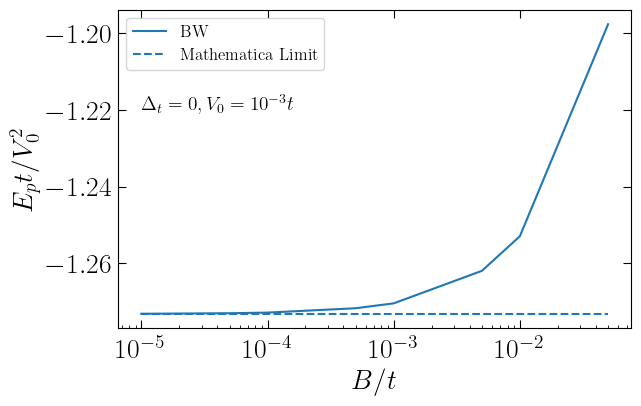

In [77]:
'''Read BW'''

V_0_arr_bw_scaling = np.array([0.001]) #,0.05,0.1])

B_bw_arr = np.array([0.00001,0.00005,0.0001,0.0005,0.001,0.005,0.01,0.05])
tx = 0.5
ty = 0.5

dir = 'data_bw/'
ebw_B_arr = np.zeros(len(B_bw_arr))
for i in range(len(B_bw_arr)):
    ebw_arr = read_bw(dir,V_0_arr_bw_scaling,B_bw_arr[i],tx,ty)[0].real
    ebw_B_arr[i] = ebw_arr

'''Plot'''
fig, ax = plt.subplots(figsize=[53 * .5**(.5 * A), 33.11 * .5**(.5 * A)])

plt.plot(B_bw_arr, ebw_B_arr.real/V_0_arr_bw_scaling[0]**2, linestyle='solid', label=r'BW')
plt.hlines(y=-1.27324, xmin=np.min(B_bw_arr), xmax=np.max(B_bw_arr), color='tab:blue', linestyle='dashed', label=r'Mathematica Limit')

plt.xscale('log')

ax.annotate(r'$\Delta_t = 0,V_0 = 10^{-3}t$', xy=(1e-5, -1.22), fontsize=0.7*font_size, color='black')
   
plt.xlabel(r'$B/t$', fontsize=font_size)
plt.ylabel(r'$E_pt/V_0^2$', fontsize=font_size)

plt.tick_params(axis='x', direction='in', length=6, top=True, pad=7, labelsize=font_size) # 4
plt.tick_params(axis='y', direction='in', length=6, right=True, labelsize=font_size)

plt.tick_params(which='minor', axis='x', direction='in', right=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

plt.legend(fontsize=0.6*font_size)

# Wavefunction Characteristics
## Polarization

In [114]:
'''
Get Polarization of Single Wavefunction
'''
V_0 = 0.7

Mx = 10
My = 10
tx_arr = 0.5
ty_arr = 0.5
B = 1e-2

qx=0.0
qy=0.0

init = 'sp'
dir='data_vgh/'
P, Px, Py = get_Px_Py(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

print('P_max =', np.max(P), ', P_min =', np.min(P), ', P_arr shape:', P.shape)

P_max = (0.9575657194582764+0j) , P_min = (7.263086457077434e-17+0j) , P_arr shape: (10, 10)


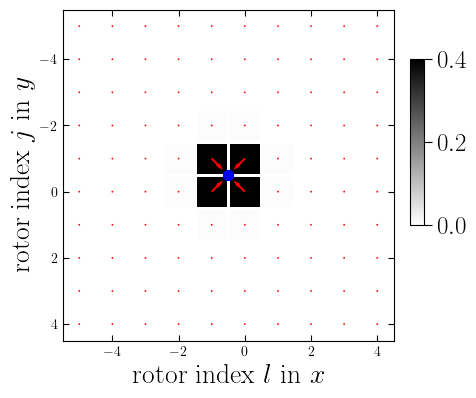

In [115]:
P_plot = P
Px_plot = Px
Py_plot = Py

x_arr = np.arange(-int(Px_plot.shape[0]/2),int(Px_plot.shape[0]/2),1)
X, Y = np.meshgrid(x_arr, x_arr) # np.meshgrid(np.arange(-4,5,1), np.arange(-4,5,1))


A = 6
plt.rc('figure', figsize=[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)])
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
font_size = 20

fig, ax = plt.subplots(figsize=[4,4]) #[46.82 * .5**(.5 * A), 33.11 * .5**(.5 * A)]) #, subplot_kw={"projection": "3d"})
ax.set_aspect("equal")

#plt.title(r'FO, $B=0.5\cdot 10^{-2}t$', fontsize=font_size)

'''Polarization Absolute Value'''
pc = plt.pcolormesh(X, Y, outfold_array(P_plot.real), cmap='binary', vmin=0.0, vmax=0.4, snap=True)#, facecolors='none') # norm=matplotlib.colors.LinNorm(vmin=0.1, vmax=1))

cax = ax.inset_axes([5, -4, 0.4, 5], transform=ax.transData)
cbar = fig.colorbar(pc, shrink=0.6, cax=cax, orientation='vertical') #, orientation="horizontal", pad=0.2)
cbar.ax.tick_params(length=6, labelsize=18)
#cbar.set_ticks(ticks=[0, 1, 2], labels=['0','1','2'])
#cbar.set_label(label=r'$\sigma^2_{\phi}/\sigma^2_0$', size=font_size)
cbar.solids.set_rasterized(True)
#pc.set_edgecolor('face')
pc.set_edgecolor('white')

'''Polarization Vector Plot'''
q = plt.quiver(X, Y, outfold_array(Px_plot), outfold_array(Py_plot), color='red', scale=20, headlength=3, headwidth=2) # flp scale=6
ax.invert_yaxis()

ax.scatter(-0.5, -0.5, marker='o', s=50, color='blue', alpha=1, zorder=2)
#ax.annotate(r'(c) $V_0/t=0.5$, FLP', xy=(0.2, -0.1), xytext=(-4.4, 3.8), fontsize=20, color='black')

plt.xlabel(r'rotor index $l$ in $x$', fontsize=font_size)
plt.ylabel(r'rotor index $j$ in $y$', fontsize=font_size)

#plt.xticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)
#plt.yticks([-4.5,-3.5,-2.5,-1.5,-0.5,0.5,1.5,2.5,3.5,4.5],[r'-5',r'',r'-3',r'',r'-1',r'1',r'',r'3',r'',r'5'], fontsize=font_size)

#plt.xlim(-5,5)
#plt.ylim(-5,5)

plt.tick_params(axis='x', direction='in', length=4, top=True)
plt.tick_params(axis='y', direction='in', length=4, right=True)
plt.tick_params(which='minor', axis='x', direction='in', top=True)
plt.tick_params(which='minor', axis='y', direction='in', right=True)

ax.set_aspect(1)
fig.set_size_inches(4.3, 4.3, forward=True)

#plt.savefig('results/configurations/pol_size/p_vec_fo.svg')

In [16]:
'''
Get Polarization for 4 States
'''
V_0 = 0.6

Mx = 10
My = 10
tx_arr = 0.5
ty_arr = 0.5
B = 1e-2

qx=0.0
qy=0.0

dir='data_vgh/'
P, Px, Py = get_Px_Py_4_states(dir=dir,init=init,Mx=Mx,My=My,tx=tx,ty=ty,qx=qx,qy=qy,B=B,V_0=V_0)

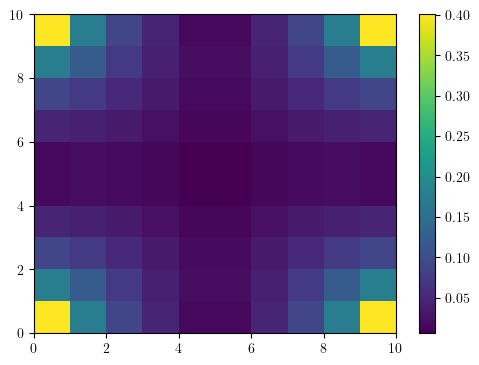

In [17]:
pc = plt.pcolormesh(P[0].real)
plt.colorbar(pc)
plt.show()